<a href="https://colab.research.google.com/github/chetan003-lab/Data-Science-Internship-Task-2/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")

In [38]:
# Load dataset

df = pd.read_csv("/content/Titanic-Dataset[1].csv")

# Display first 5 rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
df.shape

(891, 12)

In [40]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [42]:
# Check missing values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [43]:
df['Age'].fillna(df['Age'].median(), inplace=True)

In [44]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [45]:
df.drop('Cabin', axis=1, inplace=True)

In [46]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [47]:
gender_survival = df.groupby('Sex')['Survived'].sum()

gender_survival

,Survived
Sex,
female,233
male,109


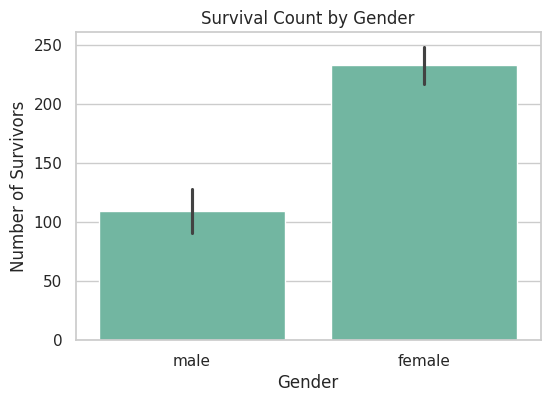

In [48]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Sex',
    y='Survived',
    data=df,
    estimator=sum
)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Survivors")

plt.show()

In [49]:
class_survival = df.groupby('Pclass')['Survived'].mean()

class_survival

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


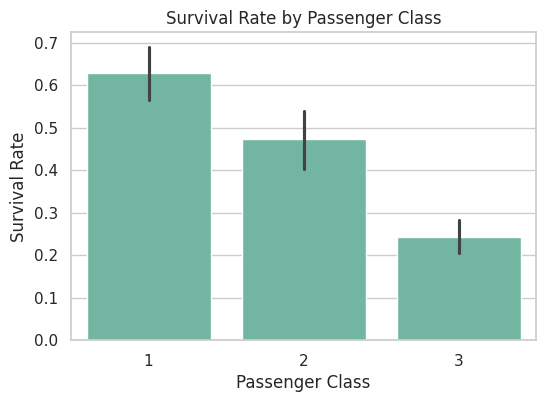

In [50]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Pclass',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [51]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,12,18,35,60,100],
    labels=[
        'Child',
        'Teenager',
        'Adult',
        'Middle Age',
        'Senior'
    ]
)

In [52]:
age_survival = df.groupby('Age_Group')['Survived'].mean()

age_survival

,Survived
Age_Group,
Child,0.579710
Teenager,0.428571
Adult,0.353271
Middle Age,0.400000
Senior,0.227273


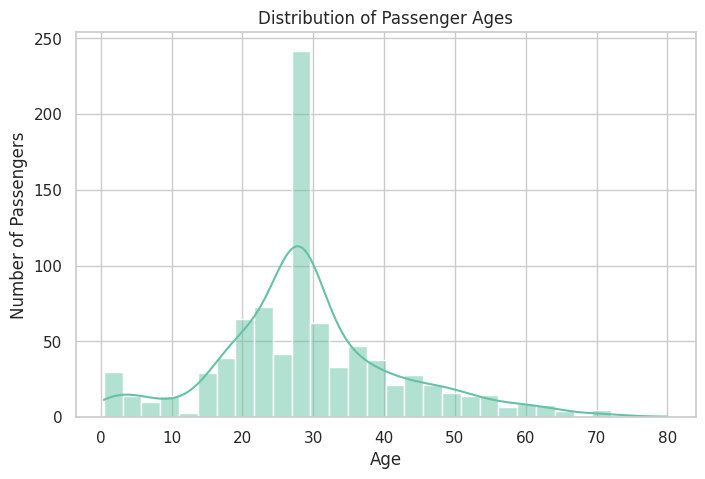

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [54]:
print("Survival by Gender:")
print(df.groupby('Sex')['Survived'].sum())


print("\nSurvival Rate by Class:")
print(df.groupby('Pclass')['Survived'].mean())


print("\nSurvival Rate by Age Group:")
print(df.groupby('Age_Group')['Survived'].mean())

Survival by Gender:
Sex
female    233
male      109
Name: Survived, dtype: int64

Survival Rate by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Age Group:
Age_Group
Child         0.579710
Teenager      0.428571
Adult         0.353271
Middle Age    0.400000
Senior        0.227273
Name: Survived, dtype: float64
